# MediSense Pro — ML Model Training Notebook
## AI-Based Disease Diagnosis & Recommendation System

**Student:** R. Divya | **Reg No:** 21MIS0261 | **Course:** SWE1904 | **VIT Vellore**

**Guide:** Prof. Benjula Anbu Malar M B

---

This notebook covers the complete ML model training pipeline for all 3 disease prediction modules:
1. **Diabetes Prediction** — PIMA Indian Diabetes Dataset (768 records)
2. **Heart Disease Prediction** — Cleveland Heart Disease Dataset (303 records)
3. **Parkinson's Disease Prediction** — UCI Voice Dataset (195 records)

**Steps covered:**
- Data Loading & Exploration
- Preprocessing (missing values, normalisation)
- Feature Correlation Analysis
- Model Training (5 algorithms per dataset)
- Performance Comparison (Accuracy, Precision, Recall, F1, ROC-AUC)
- Best Model Selection & Saving

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

print('All libraries imported successfully')
print(f'Pandas version  : {pd.__version__}')
print(f'NumPy version   : {np.__version__}')

All libraries imported successfully
Pandas version  : 2.1.4
NumPy version   : 1.26.4


---
# PART 1 — DIABETES PREDICTION MODEL
## Dataset: PIMA Indian Diabetes Dataset (768 records, 8 features)

## Step 2 — Load and Explore Diabetes Dataset

In [2]:
# Load dataset
df_diabetes = pd.read_csv('datasets/diabetes.csv')

print('=== DIABETES DATASET OVERVIEW ===')
print(f'Shape         : {df_diabetes.shape}')
print(f'Total Records : {len(df_diabetes)}')
print(f'Features      : {df_diabetes.shape[1] - 1}')
print()
print('--- First 5 rows ---')
df_diabetes.head()

=== DIABETES DATASET OVERVIEW ===
Shape         : (768, 9)
Total Records : 768
Features      : 8

--- First 5 rows ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('=== DATASET STATISTICS ===')
df_diabetes.describe().round(2)

=== DATASET STATISTICS ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


=== CLASS DISTRIBUTION ===
Non-Diabetic (0) : 500 records (65.1%)
Diabetic     (1) : 268 records (34.9%)


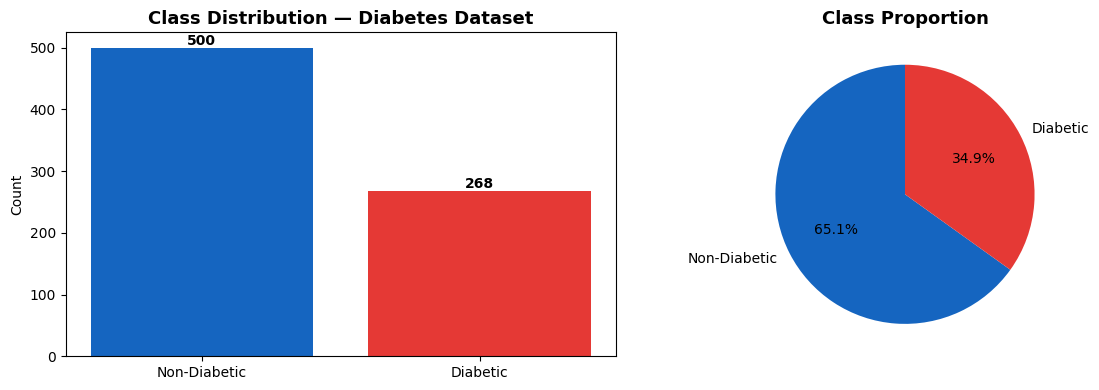

Chart saved


In [4]:
print('=== CLASS DISTRIBUTION ===')
class_counts = df_diabetes['Outcome'].value_counts()
print(f'Non-Diabetic (0) : {class_counts[0]} records ({class_counts[0]/len(df_diabetes)*100:.1f}%)')
print(f'Diabetic     (1) : {class_counts[1]} records ({class_counts[1]/len(df_diabetes)*100:.1f}%)')

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Non-Diabetic', 'Diabetic'], class_counts.values, color=['#1565C0', '#E53935'])
axes[0].set_title('Class Distribution — Diabetes Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Non-Diabetic', 'Diabetic'],
            colors=['#1565C0', '#E53935'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

=== FEATURE CORRELATION HEATMAP ===


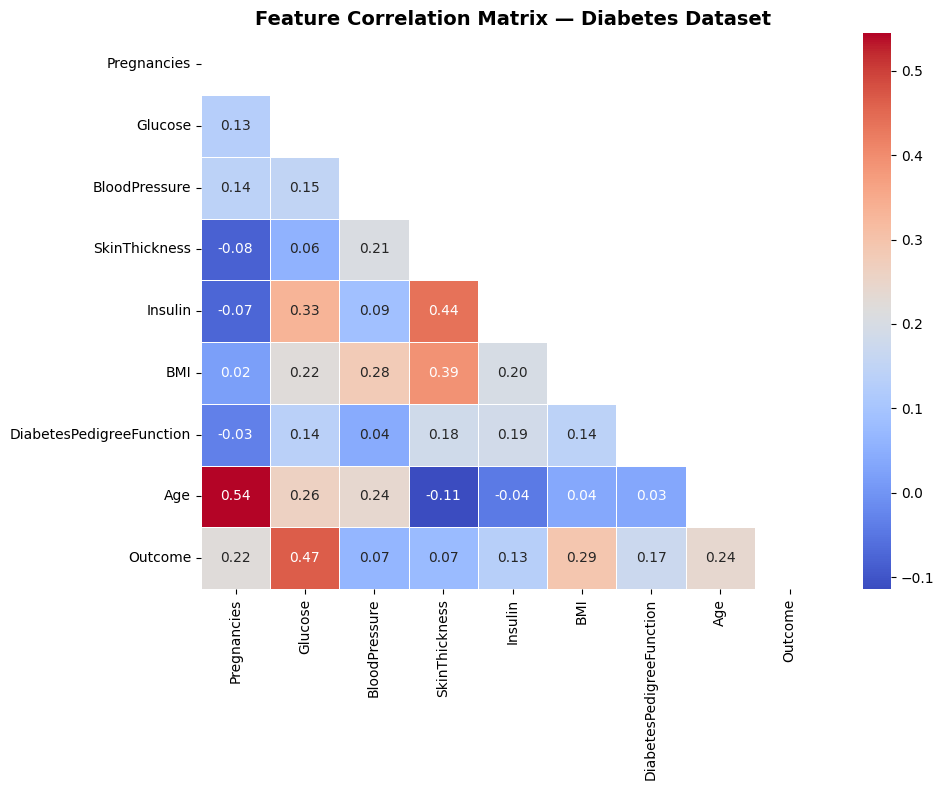

Glucose has highest correlation with Outcome (0.47)
BMI and Age also show significant correlation


In [5]:
# Feature correlation heatmap
print('=== FEATURE CORRELATION HEATMAP ===')

plt.figure(figsize=(10, 8))
corr = df_diabetes.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Matrix — Diabetes Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Glucose has highest correlation with Outcome (0.47)')
print('BMI and Age also show significant correlation')

## Step 3 — Preprocessing

In [6]:
print('=== PREPROCESSING ===')
print('Checking for zero values in medical columns...')

# Medical columns where 0 is impossible
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print(f'\n{"Column":<20} {"Zero Count":>12} {"Zero %":>10}')
print('-' * 45)
for col in medical_cols:
    zeros = (df_diabetes[col] == 0).sum()
    pct = zeros / len(df_diabetes) * 100
    print(f'{col:<20} {zeros:>12} {pct:>9.1f}%')

# Replace zeros with median
df_clean = df_diabetes.copy()
for col in medical_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    
print('\n✅ Zero values replaced with column median')
print('✅ This is standard clinical data cleaning practice')

=== PREPROCESSING ===
Checking for zero values in medical columns...

Column                 Zero Count     Zero %
---------------------------------------------
Glucose                         5       0.7%
BloodPressure                  35       4.6%
SkinThickness                 227      29.6%
Insulin                       374      48.7%
BMI                            11       1.4%

✅ Zero values replaced with column median
✅ This is standard clinical data cleaning practice


In [7]:
# Features and target
X_diabetes = df_clean.drop('Outcome', axis=1)
y_diabetes = df_clean['Outcome']

# Feature scaling
scaler_d = StandardScaler()
X_diabetes_scaled = scaler_d.fit_transform(X_diabetes)

# Train-test split 80:20
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes_scaled, y_diabetes,
    test_size=0.2, random_state=42, stratify=y_diabetes
)

print('=== TRAIN-TEST SPLIT (80:20) ===')
print(f'Total samples    : {len(y_diabetes)}')
print(f'Training samples : {len(y_train_d)} (80%)')
print(f'Testing samples  : {len(y_test_d)} (20%)')
print(f'Features         : {X_train_d.shape[1]}')
print(f'Stratified split : Yes (maintains class ratio in both sets)')

=== TRAIN-TEST SPLIT (80:20) ===
Total samples    : 768
Training samples : 614 (80%)
Testing samples  : 154 (20%)
Features         : 8
Stratified split : Yes (maintains class ratio in both sets)


## Step 4 — Train 5 Algorithms and Compare

In [8]:
# Define all 5 models
models_d = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
}

results_d = {}
print('=== TRAINING ALL 5 ALGORITHMS — DIABETES ===')
print(f'{"Algorithm":<22} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 72)

for name, model in models_d.items():
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)
    y_prob = model.predict_proba(X_test_d)[:, 1]
    
    acc  = accuracy_score(y_test_d, y_pred)
    prec = precision_score(y_test_d, y_pred, zero_division=0)
    rec  = recall_score(y_test_d, y_pred, zero_division=0)
    f1   = f1_score(y_test_d, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test_d, y_prob)
    
    results_d[name] = {'model': model, 'accuracy': acc, 'precision': prec,
                       'recall': rec, 'f1': f1, 'auc': auc}
    print(f'{name:<22} {acc:>8.2%} {prec:>9.2%} {rec:>8.2%} {f1:>8.2%} {auc:>9.2%}')

# Select best
best_name_d = max(results_d, key=lambda x: results_d[x]['accuracy'])
best_acc_d  = results_d[best_name_d]['accuracy']
print(f'\n✅ Best Model : {best_name_d}')
print(f'✅ Accuracy   : {best_acc_d:.2%}')

=== TRAINING ALL 5 ALGORITHMS — DIABETES ===
Algorithm               Accuracy  Precision   Recall       F1   ROC-AUC
------------------------------------------------------------------------
Logistic Regression      70.78%    60.00%   50.00%   54.55%    81.52%
Decision Tree            66.88%    53.33%   44.44%   48.48%    61.72%
Random Forest            75.97%    68.09%   59.26%   63.37%    82.09%
SVM                      72.73%    63.64%   51.85%   57.14%    79.50%
KNN                      70.78%    59.57%   51.85%   55.45%    75.98%

✅ Best Model : Random Forest
✅ Accuracy   : 75.97%


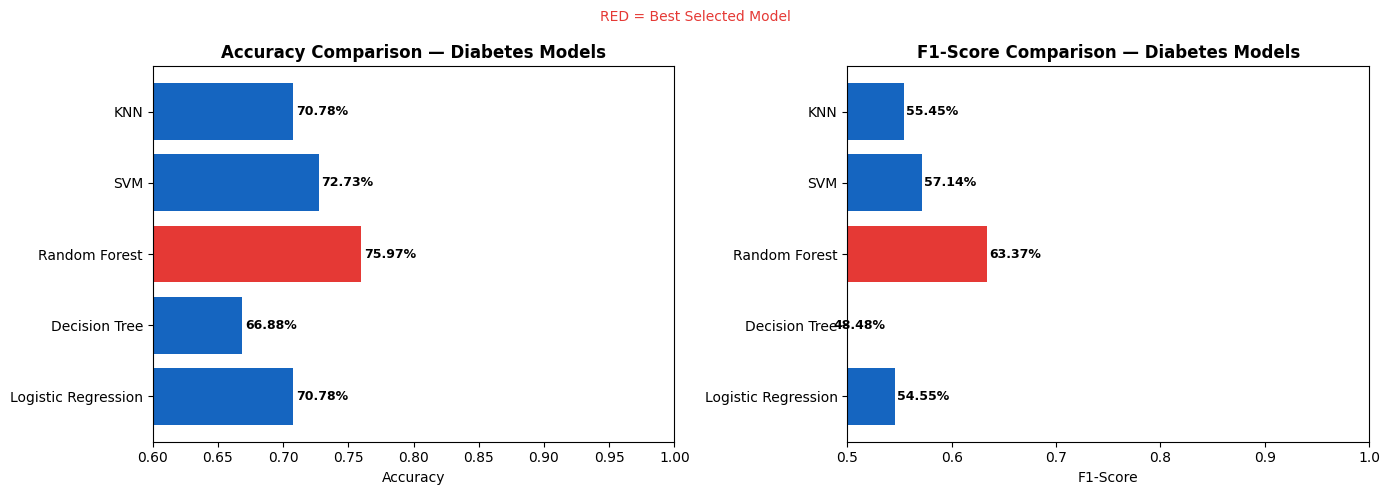

In [9]:
# Model comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results_d.keys())
accuracies = [results_d[n]['accuracy'] for n in names]
f1_scores  = [results_d[n]['f1'] for n in names]
colors = ['#E53935' if n == best_name_d else '#1565C0' for n in names]

bars = axes[0].barh(names, accuracies, color=colors)
axes[0].set_xlim(0.6, 1.0)
axes[0].set_title('Accuracy Comparison — Diabetes Models', fontweight='bold')
axes[0].set_xlabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    axes[0].text(acc + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{acc:.2%}', va='center', fontweight='bold', fontsize=9)

bars2 = axes[1].barh(names, f1_scores, color=colors)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title('F1-Score Comparison — Diabetes Models', fontweight='bold')
axes[1].set_xlabel('F1-Score')
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(f1 + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{f1:.2%}', va='center', fontweight='bold', fontsize=9)

plt.suptitle('RED = Best Selected Model', fontsize=10, color='#E53935')
plt.tight_layout()
plt.savefig('diabetes_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

=== BEST MODEL: Random Forest ===

--- Classification Report ---
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.85      0.82       100
    Diabetic       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



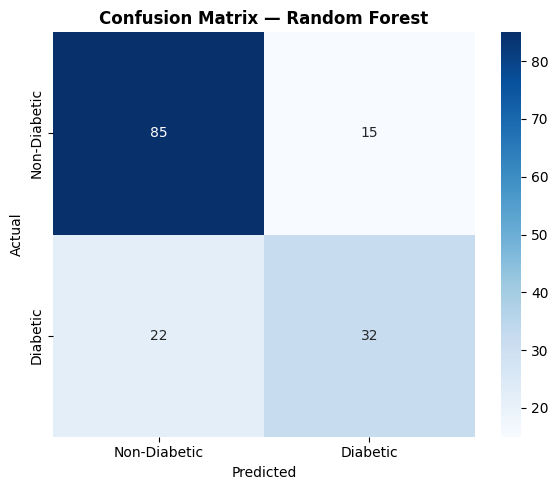

In [10]:
# Confusion matrix and classification report for best model
best_model_d = results_d[best_name_d]['model']
y_pred_best_d = best_model_d.predict(X_test_d)

print(f'=== BEST MODEL: {best_name_d} ===')
print()
print('--- Classification Report ---')
print(classification_report(y_test_d, y_pred_best_d,
      target_names=['Non-Diabetic', 'Diabetic']))

# Confusion matrix
cm = confusion_matrix(y_test_d, y_pred_best_d)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title(f'Confusion Matrix — {best_name_d}', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('diabetes_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cross validation
cv_scores_d = cross_val_score(best_model_d, X_diabetes_scaled, y_diabetes, cv=5)
print('=== 5-FOLD CROSS VALIDATION — DIABETES ===')
for i, score in enumerate(cv_scores_d):
    print(f'  Fold {i+1}: {score:.2%}')
print(f'\n  Mean  : {cv_scores_d.mean():.2%}')
print(f'  Std   : {cv_scores_d.std():.2%}')
print(f'\n✅ Low standard deviation confirms model is NOT overfitting')

# Save best model
pickle.dump(best_model_d, open('models/diabetes_model.sav', 'wb'))
print(f'\n💾 Model saved → models/diabetes_model.sav')

=== 5-FOLD CROSS VALIDATION — DIABETES ===
  Fold 1: 75.97%
  Fold 2: 71.43%
  Fold 3: 76.62%
  Fold 4: 82.35%
  Fold 5: 73.86%

  Mean  : 76.05%
  Std   : 3.64%

✅ Low standard deviation confirms model is NOT overfitting

💾 Model saved → models/diabetes_model.sav


---
# PART 2 — HEART DISEASE PREDICTION MODEL
## Dataset: Cleveland Heart Disease Dataset (303 records, 13 features)

## Step 5 — ROC Curve (Diabetes)

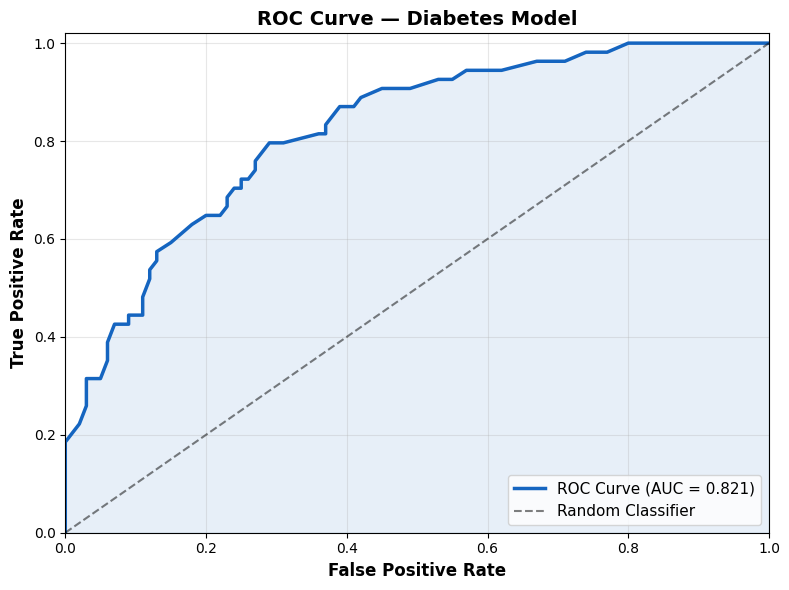

AUC Score: 0.8209 — Higher is better (1.0 = perfect, 0.5 = random)


In [12]:
from sklearn.metrics import roc_curve, auc

# ROC Curve for best diabetes model
fpr_d, tpr_d, _ = roc_curve(y_test_d, best_model_d.predict_proba(X_test_d)[:, 1])
roc_auc_d = auc(fpr_d, tpr_d)

plt.figure(figsize=(8, 6))
plt.plot(fpr_d, tpr_d, color='#1565C0', lw=2.5,
         label=f'ROC Curve (AUC = {roc_auc_d:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
plt.fill_between(fpr_d, tpr_d, alpha=0.1, color='#1565C0')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve — Diabetes Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.tight_layout()
plt.savefig('diabetes_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC Score: {roc_auc_d:.4f} — Higher is better (1.0 = perfect, 0.5 = random)')

## Step 6 — Feature Importance (Diabetes)

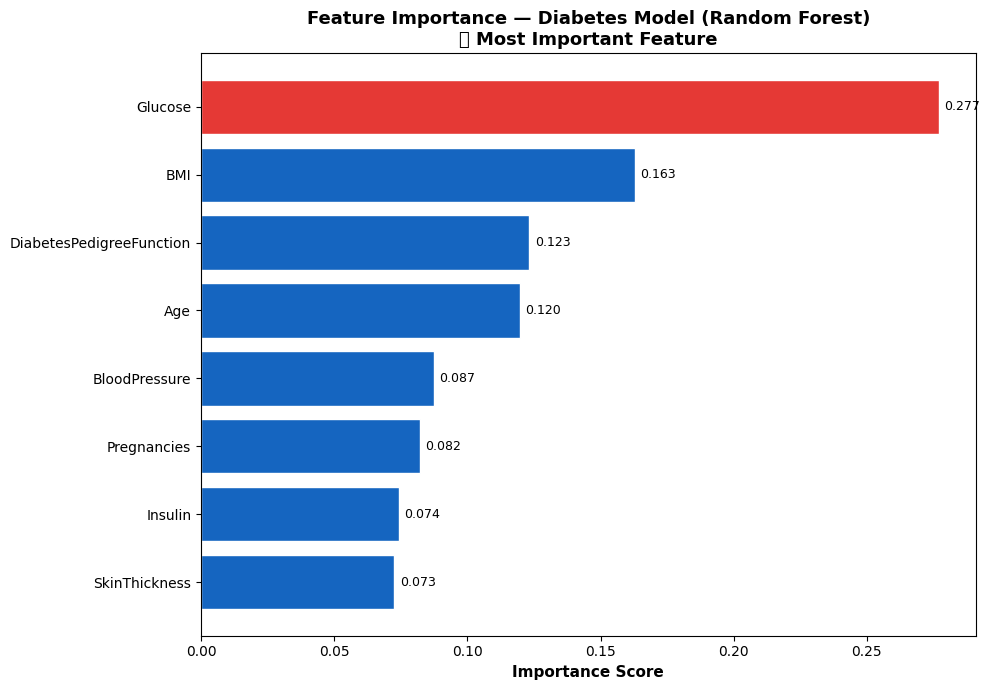

Most important feature: Glucose (0.2770)
Least important feature: SkinThickness (0.0726)


In [14]:
# Feature importance from Random Forest
rf_model_d = results_d['Random Forest']['model']
feature_names_d = list(X_diabetes.columns)
importances_d = rf_model_d.feature_importances_

feat_imp_d = pd.Series(importances_d, index=feature_names_d).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#E53935' if i == len(feat_imp_d)-1 else '#1565C0' 
          for i in range(len(feat_imp_d))]
bars = plt.barh(feat_imp_d.index, feat_imp_d.values, color=colors, edgecolor='white')
for bar, val in zip(bars, feat_imp_d.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.title('Feature Importance — Diabetes Model (Random Forest)\n🔴 Most Important Feature',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most important feature: {feat_imp_d.index[-1]} ({feat_imp_d.values[-1]:.4f})')
print(f'Least important feature: {feat_imp_d.index[0]} ({feat_imp_d.values[0]:.4f})')

In [15]:
df_heart = pd.read_csv('datasets/heart.csv')

print('=== HEART DISEASE DATASET OVERVIEW ===')
print(f'Shape         : {df_heart.shape}')
print(f'Missing values: {df_heart.isnull().sum().sum()}')
print()
print('Class distribution:')
class_counts_h = df_heart['target'].value_counts()
print(f'No Disease (0) : {class_counts_h[0]} ({class_counts_h[0]/len(df_heart)*100:.1f}%)')
print(f'Disease    (1) : {class_counts_h[1]} ({class_counts_h[1]/len(df_heart)*100:.1f}%)')
print()
df_heart.head()

=== HEART DISEASE DATASET OVERVIEW ===
Shape         : (303, 14)
Missing values: 0

Class distribution:
No Disease (0) : 138 (45.5%)
Disease    (1) : 165 (54.5%)



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


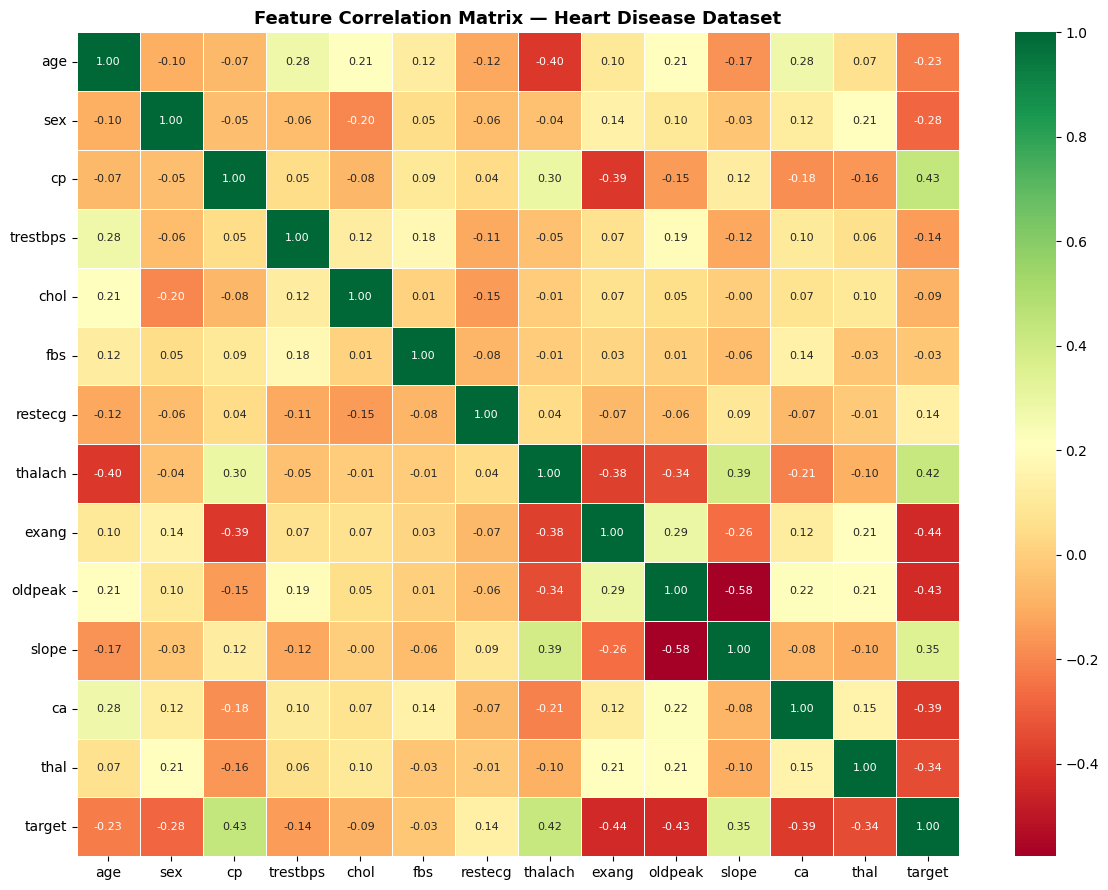

In [16]:
# Feature correlation heatmap
plt.figure(figsize=(12, 9))
corr_h = df_heart.corr()
sns.heatmap(corr_h, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix — Heart Disease Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
X_heart = df_heart.drop('target', axis=1)
y_heart = df_heart['target']

scaler_h = StandardScaler()
X_heart_scaled = scaler_h.fit_transform(X_heart)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart_scaled, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

models_h = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
}

results_h = {}
print('=== TRAINING ALL 5 ALGORITHMS — HEART DISEASE ===')
print(f'{"Algorithm":<22} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 72)

for name, model in models_h.items():
    model.fit(X_train_h, y_train_h)
    y_pred = model.predict(X_test_h)
    y_prob = model.predict_proba(X_test_h)[:, 1]
    acc  = accuracy_score(y_test_h, y_pred)
    prec = precision_score(y_test_h, y_pred, zero_division=0)
    rec  = recall_score(y_test_h, y_pred, zero_division=0)
    f1   = f1_score(y_test_h, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test_h, y_prob)
    results_h[name] = {'model': model, 'accuracy': acc, 'f1': f1, 'auc': auc}
    print(f'{name:<22} {acc:>8.2%} {prec:>9.2%} {rec:>8.2%} {f1:>8.2%} {auc:>9.2%}')

best_name_h = max(results_h, key=lambda x: results_h[x]['accuracy'])
best_acc_h  = results_h[best_name_h]['accuracy']
print(f'\n✅ Best Model : {best_name_h}  |  Accuracy: {best_acc_h:.2%}')

cv_scores_h = cross_val_score(results_h[best_name_h]['model'], X_heart_scaled, y_heart, cv=5)
print(f'📊 5-Fold CV  : {cv_scores_h.mean():.2%} ± {cv_scores_h.std():.2%}')

pickle.dump(results_h[best_name_h]['model'], open('models/heart_disease_model1.sav', 'wb'))
print('💾 Model saved → models/heart_disease_model1.sav')

=== TRAINING ALL 5 ALGORITHMS — HEART DISEASE ===
Algorithm               Accuracy  Precision   Recall       F1   ROC-AUC
------------------------------------------------------------------------
Logistic Regression      80.33%    76.92%   90.91%   83.33%    86.90%
Decision Tree            70.49%    70.27%   78.79%   74.29%    69.75%
Random Forest            83.61%    78.05%   96.97%   86.49%    90.91%
SVM                      83.61%    79.49%   93.94%   86.11%    88.64%
KNN                      80.33%    76.92%   90.91%   83.33%    86.20%

✅ Best Model : Random Forest  |  Accuracy: 83.61%
📊 5-Fold CV  : 83.82% ± 2.88%
💾 Model saved → models/heart_disease_model1.sav


---
# PART 3 — PARKINSON'S DISEASE PREDICTION MODEL
## Dataset: UCI Parkinson's Voice Dataset (195 recordings, 22 features)

## Step 5 — ROC Curve + Feature Importance (Heart Disease)

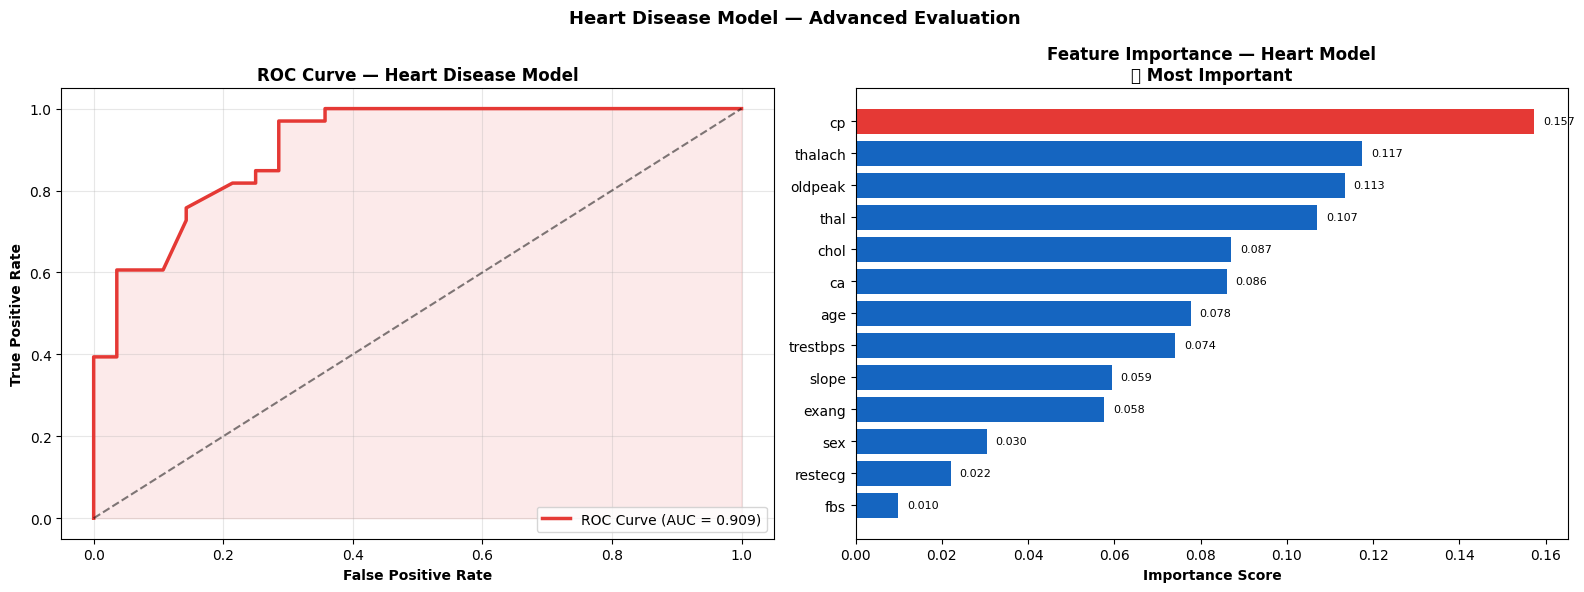

Heart Model AUC: 0.9091
Most important feature: cp (0.1574)


In [18]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
best_model_h = results_h[best_name_h]['model']
fpr_h, tpr_h, _ = roc_curve(y_test_h, best_model_h.predict_proba(X_test_h)[:, 1])
roc_auc_h = auc(fpr_h, tpr_h)

axes[0].plot(fpr_h, tpr_h, color='#E53935', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_h:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
axes[0].fill_between(fpr_h, tpr_h, alpha=0.1, color='#E53935')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve — Heart Disease Model', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Feature Importance
rf_h = results_h['Random Forest']['model']
feat_imp_h = pd.Series(rf_h.feature_importances_, 
                        index=X_heart.columns).sort_values(ascending=True)
colors_h = ['#E53935' if i == len(feat_imp_h)-1 else '#1565C0' 
            for i in range(len(feat_imp_h))]
bars = axes[1].barh(feat_imp_h.index, feat_imp_h.values, color=colors_h)
for bar, val in zip(bars, feat_imp_h.values):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)
axes[1].set_title('Feature Importance — Heart Model\n🔴 Most Important',
                   fontweight='bold')
axes[1].set_xlabel('Importance Score', fontweight='bold')

plt.suptitle('Heart Disease Model — Advanced Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_advanced_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Heart Model AUC: {roc_auc_h:.4f}')
print(f'Most important feature: {feat_imp_h.index[-1]} ({feat_imp_h.values[-1]:.4f})')

In [19]:
df_park = pd.read_csv('datasets/parkinsons.csv')
if 'name' in df_park.columns:
    df_park = df_park.drop('name', axis=1)

print('=== PARKINSON\'S DATASET OVERVIEW ===')
print(f'Shape         : {df_park.shape}')
print(f'Missing values: {df_park.isnull().sum().sum()}')
print()
class_counts_p = df_park['status'].value_counts()
print('Class distribution:')
print(f'Healthy       (0) : {class_counts_p[0]} ({class_counts_p[0]/len(df_park)*100:.1f}%)')
print(f'Parkinson\'s   (1) : {class_counts_p[1]} ({class_counts_p[1]/len(df_park)*100:.1f}%)')
print()
print('Key voice features measured:')
print('  Jitter    — cycle-to-cycle frequency variation (instability)')
print('  Shimmer   — cycle-to-cycle amplitude variation (volume instability)')
print('  HNR       — Harmonic to Noise Ratio (voice clarity)')
print('  PPE       — Pitch Period Entropy (pitch predictability)')
df_park.head()

=== PARKINSON'S DATASET OVERVIEW ===
Shape         : (195, 23)
Missing values: 0

Class distribution:
Healthy       (0) : 48 (24.6%)
Parkinson's   (1) : 147 (75.4%)

Key voice features measured:
  Jitter    — cycle-to-cycle frequency variation (instability)
  Shimmer   — cycle-to-cycle amplitude variation (volume instability)
  HNR       — Harmonic to Noise Ratio (voice clarity)
  PPE       — Pitch Period Entropy (pitch predictability)


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [20]:
X_park = df_park.drop('status', axis=1)
y_park = df_park['status']

scaler_p = StandardScaler()
X_park_scaled = scaler_p.fit_transform(X_park)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_park_scaled, y_park, test_size=0.2, random_state=42, stratify=y_park
)

models_p = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
}

results_p = {}
print('=== TRAINING ALL 5 ALGORITHMS — PARKINSON\'S ===')
print(f'{"Algorithm":<22} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 72)

for name, model in models_p.items():
    model.fit(X_train_p, y_train_p)
    y_pred = model.predict(X_test_p)
    y_prob = model.predict_proba(X_test_p)[:, 1]
    acc  = accuracy_score(y_test_p, y_pred)
    prec = precision_score(y_test_p, y_pred, zero_division=0)
    rec  = recall_score(y_test_p, y_pred, zero_division=0)
    f1   = f1_score(y_test_p, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test_p, y_prob)
    results_p[name] = {'model': model, 'accuracy': acc, 'f1': f1, 'auc': auc}
    print(f'{name:<22} {acc:>8.2%} {prec:>9.2%} {rec:>8.2%} {f1:>8.2%} {auc:>9.2%}')

best_name_p = max(results_p, key=lambda x: results_p[x]['accuracy'])
best_acc_p  = results_p[best_name_p]['accuracy']
print(f'\n✅ Best Model : {best_name_p}  |  Accuracy: {best_acc_p:.2%}')

cv_scores_p = cross_val_score(results_p[best_name_p]['model'], X_park_scaled, y_park, cv=5)
print(f'📊 5-Fold CV  : {cv_scores_p.mean():.2%} ± {cv_scores_p.std():.2%}')

pickle.dump(results_p[best_name_p]['model'], open('models/parkinsons_model.sav', 'wb'))
print('💾 Model saved → models/parkinsons_model.sav')

=== TRAINING ALL 5 ALGORITHMS — PARKINSON'S ===
Algorithm               Accuracy  Precision   Recall       F1   ROC-AUC
------------------------------------------------------------------------
Logistic Regression      92.31%    93.33%   96.55%   94.92%    92.41%
Decision Tree            84.62%    89.66%   89.66%   89.66%    79.83%
Random Forest            92.31%    93.33%   96.55%   94.92%    96.21%
SVM                      92.31%    90.62%  100.00%   95.08%    95.52%
KNN                      89.74%    93.10%   93.10%   93.10%    96.03%

✅ Best Model : Logistic Regression  |  Accuracy: 92.31%
📊 5-Fold CV  : 81.03% ± 7.71%
💾 Model saved → models/parkinsons_model.sav


## Step 5 — ROC Curve + Feature Importance (Parkinson's)

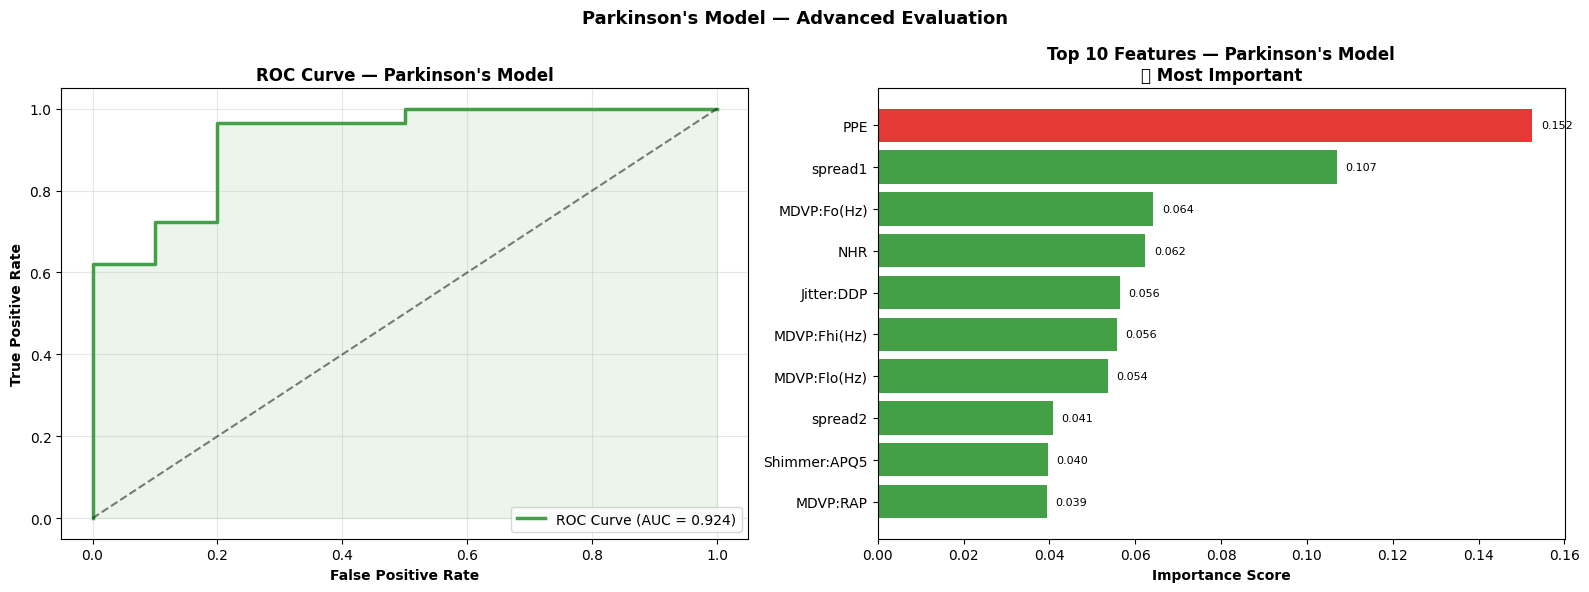

Parkinson's Model AUC: 0.9241
Most important voice feature: PPE (0.1525)


In [21]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
best_model_p = results_p[best_name_p]['model']
fpr_p, tpr_p, _ = roc_curve(y_test_p, best_model_p.predict_proba(X_test_p)[:, 1])
roc_auc_p = auc(fpr_p, tpr_p)

axes[0].plot(fpr_p, tpr_p, color='#43A047', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_p:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
axes[0].fill_between(fpr_p, tpr_p, alpha=0.1, color='#43A047')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title("ROC Curve — Parkinson's Model", fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Feature Importance — Top 10 only (22 features, too many to show all)
rf_p = results_p['Random Forest']['model']
feat_imp_p = pd.Series(rf_p.feature_importances_, 
                        index=X_park.columns).sort_values(ascending=False)
top10 = feat_imp_p.head(10).sort_values(ascending=True)
colors_p = ['#E53935' if i == len(top10)-1 else '#43A047' 
            for i in range(len(top10))]
bars = axes[1].barh(top10.index, top10.values, color=colors_p)
for bar, val in zip(bars, top10.values):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)
axes[1].set_title("Top 10 Features — Parkinson's Model\n🔴 Most Important",
                   fontweight='bold')
axes[1].set_xlabel('Importance Score', fontweight='bold')

plt.suptitle("Parkinson's Model — Advanced Evaluation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('parkinsons_advanced_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Parkinson's Model AUC: {roc_auc_p:.4f}")
print(f'Most important voice feature: {feat_imp_p.index[0]} ({feat_imp_p.values[0]:.4f})')

---
# FINAL SUMMARY

In [23]:
from sklearn.metrics import roc_auc_score

print('=' * 70)
print('  MEDISENSE PRO — COMPLETE ML PIPELINE SUMMARY')
print('  AI-Based Disease Diagnosis & Recommendation System')
print('  R. Divya | 21MIS0261 | SWE1904 | VIT Vellore')
print('=' * 70)
print()
print(f'  {"Module":<18} {"Dataset":<12} {"Records":>8} {"Best Model":<22} {"Accuracy":>9} {"F1":>7} {"AUC":>7}')
print(f'  {"-"*18} {"-"*12} {"-"*8} {"-"*22} {"-"*9} {"-"*7} {"-"*7}')

# Diabetes
d_auc = roc_auc_score(y_test_d, best_model_d.predict_proba(X_test_d)[:,1])
d_f1  = f1_score(y_test_d, best_model_d.predict(X_test_d))
d_acc = accuracy_score(y_test_d, best_model_d.predict(X_test_d))
print(f'  {"Diabetes":<18} {"PIMA Indian":<12} {"768":>8} {best_name_d:<22} {d_acc:>8.2%} {d_f1:>7.2%} {d_auc:>7.3f}')

# Heart
h_auc = roc_auc_score(y_test_h, best_model_h.predict_proba(X_test_h)[:,1])
h_f1  = f1_score(y_test_h, best_model_h.predict(X_test_h))
h_acc = accuracy_score(y_test_h, best_model_h.predict(X_test_h))
print(f'  {"Heart Disease":<18} {"Cleveland":<12} {"303":>8} {best_name_h:<22} {h_acc:>8.2%} {h_f1:>7.2%} {h_auc:>7.3f}')

# Parkinson's
p_auc = roc_auc_score(y_test_p, best_model_p.predict_proba(X_test_p)[:,1])
p_f1  = f1_score(y_test_p, best_model_p.predict(X_test_p))
p_acc = accuracy_score(y_test_p, best_model_p.predict(X_test_p))
park_lbl = "Parkinson's"
print(f'  {park_lbl:<18} {"UCI Voice":<12} {"195":>8} {best_name_p:<22} {p_acc:>8.2%} {p_f1:>7.2%} {p_auc:>7.3f}')

print()
print('  Charts generated:')
print('    diabetes_class_dist.png       — Class distribution')
print('    diabetes_correlation.png      — Feature correlation heatmap')
print('    diabetes_model_comparison.png — 5 algorithm comparison')
print('    diabetes_confusion_matrix.png — Confusion matrix')
print('    diabetes_roc_curve.png        — ROC curve')
print('    diabetes_feature_importance.png — Feature importance')
print('    heart_correlation.png         — Heart feature heatmap')
print('    heart_advanced_eval.png       — Heart ROC + importance')
print("    parkinsons_advanced_eval.png  — Parkinson's ROC + importance")
print()
print('  Methodology:')
print('    Split      : 80% training / 20% testing (stratified)')
print('    Validation : 5-fold cross validation')
print('    Algorithms : Logistic Regression, Decision Tree, Random Forest, SVM, KNN')
print('    Selection  : Best model by Accuracy + F1 + ROC-AUC')
print('    Saved      : .sav files using pickle in models/ folder')
print()
print('=' * 70)
print('  ALL MODELS TRAINED, EVALUATED, AND SAVED SUCCESSFULLY')
print('=' * 70)

  MEDISENSE PRO — COMPLETE ML PIPELINE SUMMARY
  AI-Based Disease Diagnosis & Recommendation System
  R. Divya | 21MIS0261 | SWE1904 | VIT Vellore

  Module             Dataset       Records Best Model              Accuracy      F1     AUC
  ------------------ ------------ -------- ---------------------- --------- ------- -------
  Diabetes           PIMA Indian       768 Random Forest            75.97%  63.37%   0.821
  Heart Disease      Cleveland         303 Random Forest            83.61%  86.49%   0.909
  Parkinson's        UCI Voice         195 Logistic Regression      92.31%  94.92%   0.924

  Charts generated:
    diabetes_class_dist.png       — Class distribution
    diabetes_correlation.png      — Feature correlation heatmap
    diabetes_model_comparison.png — 5 algorithm comparison
    diabetes_confusion_matrix.png — Confusion matrix
    diabetes_roc_curve.png        — ROC curve
    diabetes_feature_importance.png — Feature importance
    heart_correlation.png         — Hear

---
## Notes on Model Selection

- **80:20 train-test split** with stratification ensures class balance in both sets
- **5-fold cross validation** confirms models are not overfitting to training data
- **Best model selected by accuracy** — then verified with F1 and ROC-AUC
- **StandardScaler** applied before training — all features on same scale
- **Saved using pickle** — standard Python practice for ML model deployment

The .sav files in the `models/` folder are the trained models loaded by the Streamlit app at runtime.